# 01 - Khám phá dữ liệu (EDA)
BTL môn Trí tuệ nhân tạo — Dữ liệu mô phỏng: `du_lieu_sinh_vien_mophong.csv`

## Bước 1: Đọc dữ liệu

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/du_lieu_sinh_vien_mophong.csv")
df.head()

,GioiTinh,KhuVucSinhSong,HocVanChaMe,HoanCanhGiaDinh,HocLucNamTruoc,TiLeChuyenCan,GioTuHocMoiTuan,ThamGiaHocThem,OnThiTruoc,ThoiGianMangXaHoi,KetQua
0,Nam,Thành thị,Tốt nghiệp THPT,Trung bình,Trung bình,94.4,11.1,Có,Đã ôn thi,2.0,Đỗ
1,Nam,Thành thị,Đại học,Khá giả,Khá,97.0,12.2,Có,Đã ôn thi,5.8,Đỗ
2,Nữ,Nông thôn,Đại học,Trung bình,Khá,84.5,10.7,Có,Đã ôn thi,3.8,Đỗ
3,Nam,Nông thôn,Đại học,Trung bình,Khá,73.1,6.8,Không,Đã ôn thi,5.1,Đỗ
4,Nữ,Thành thị,Thạc sĩ,Khó khăn,Trung bình,93.4,12.8,Không,Đã ôn thi,7.7,Trượt


## Bước 2: Thông tin tổng quan

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GioiTinh           1500 non-null   str    
 1   KhuVucSinhSong     1500 non-null   str    
 2   HocVanChaMe        1500 non-null   str    
 3   HoanCanhGiaDinh    1500 non-null   str    
 4   HocLucNamTruoc     1500 non-null   str    
 5   TiLeChuyenCan      1500 non-null   float64
 6   GioTuHocMoiTuan    1500 non-null   float64
 7   ThamGiaHocThem     1500 non-null   str    
 8   OnThiTruoc         1500 non-null   str    
 9   ThoiGianMangXaHoi  1500 non-null   float64
 10  KetQua             1500 non-null   str    
dtypes: float64(3), str(8)
memory usage: 234.3 KB


In [3]:
df.describe()

,TiLeChuyenCan,GioTuHocMoiTuan,ThoiGianMangXaHoi
count,1500.000000,1500.000000,1500.000000
mean,83.764267,9.141200,3.496400
std,11.208976,5.081711,1.725286
min,50.200000,0.000000,0.000000
25%,76.000000,5.400000,2.300000
50%,84.250000,8.900000,3.500000
75%,92.900000,12.700000,4.600000
max,100.000000,26.600000,9.600000


In [4]:
df.shape

(1500, 11)

## Bước 3: Kiểm tra dữ liệu thiếu

In [5]:
df.isnull().sum()

GioiTinh             0
KhuVucSinhSong       0
HocVanChaMe          0
HoanCanhGiaDinh      0
HocLucNamTruoc       0
TiLeChuyenCan        0
GioTuHocMoiTuan      0
ThamGiaHocThem       0
OnThiTruoc           0
ThoiGianMangXaHoi    0
KetQua               0
dtype: int64

## Bước 4: Phân bố nhãn Đỗ/Trượt

In [6]:
print(df['KetQua'].value_counts())
print(df['KetQua'].value_counts(normalize=True))

KetQua
Đỗ       975
Trượt    525
Name: count, dtype: int64
KetQua
Đỗ       0.65
Trượt    0.35
Name: proportion, dtype: float64


## Bước 5: Biểu đồ khám phá dữ liệu

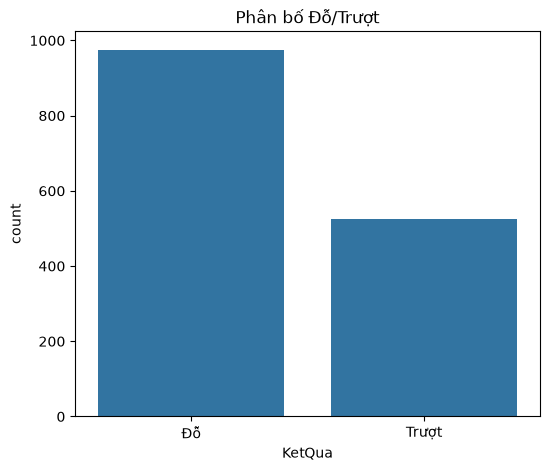

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results/figures", exist_ok=True)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='KetQua')
plt.title("Phân bố Đỗ/Trượt")
plt.savefig("../results/figures/phan_bo_ketqua.png")
plt.show()

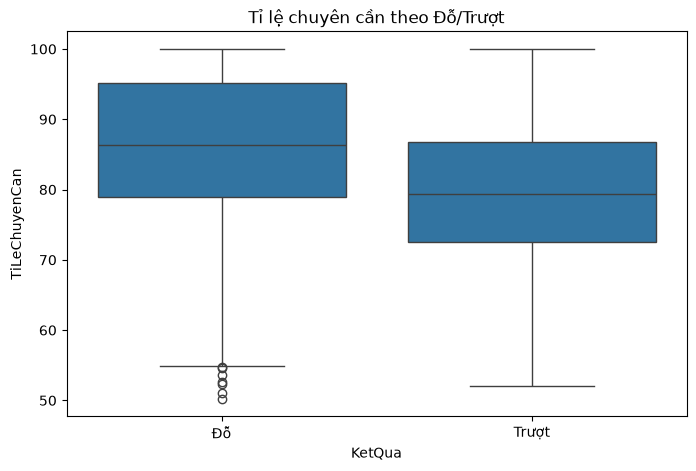

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='KetQua', y='TiLeChuyenCan')
plt.title("Tỉ lệ chuyên cần theo Đỗ/Trượt")
plt.savefig("../results/figures/chuyencan_theo_ketqua.png")
plt.show()

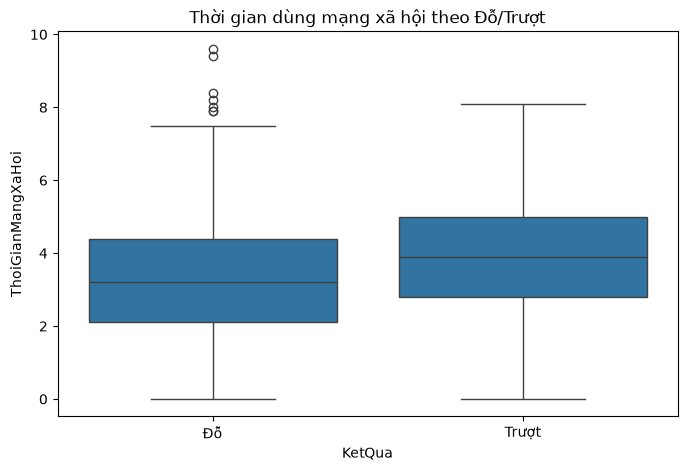

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='KetQua', y='ThoiGianMangXaHoi')
plt.title("Thời gian dùng mạng xã hội theo Đỗ/Trượt")
plt.savefig("../results/figures/mxh_theo_ketqua.png")
plt.show()

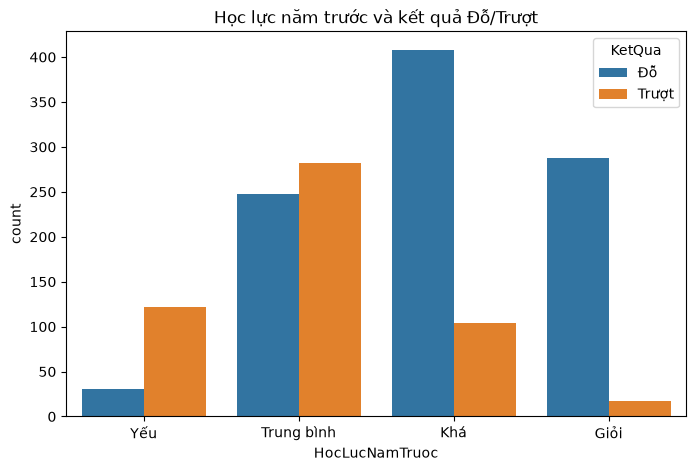

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='HocLucNamTruoc', hue='KetQua',
              order=['Yếu', 'Trung bình', 'Khá', 'Giỏi'])
plt.title("Học lực năm trước và kết quả Đỗ/Trượt")
plt.savefig("../results/figures/hocluc_theo_ketqua.png")
plt.show()

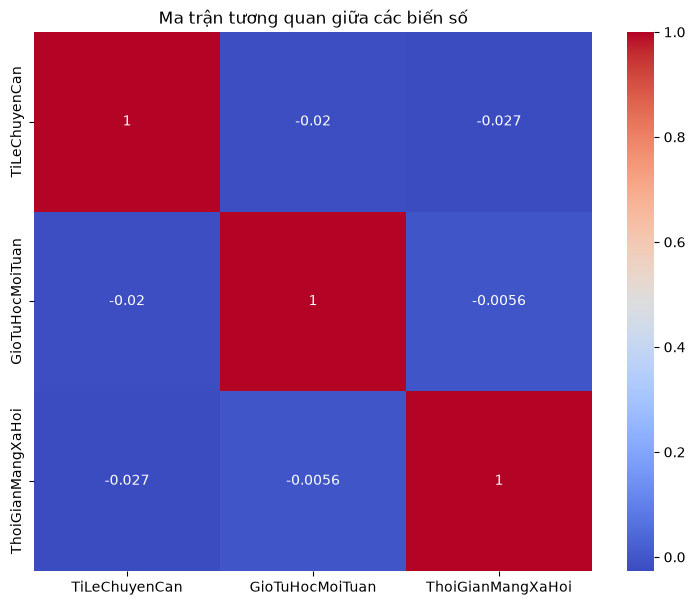

In [11]:
plt.figure(figsize=(9, 7))
numeric_cols = ['TiLeChuyenCan', 'GioTuHocMoiTuan', 'ThoiGianMangXaHoi']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Ma trận tương quan giữa các biến số")
plt.savefig("../results/figures/correlation_heatmap.png")
plt.show()